In [38]:
###
import pandas as pd
import numpy as np

didx2 = didx.copy()

didx2["StudyDate"] = didx2["StudyDate"].astype(str).str.strip()
didx2["StudyTime"] = didx2["StudyTime"].astype(str).str.strip()

# normalize StudyTime to 6 digits (HHMMSS)
didx2["StudyTime"] = didx2["StudyTime"].str.replace(".", "", regex=False).str.pad(6, side="right", fillchar="0").str[:6]
didx2["dt_key"] = didx2["StudyDate"] + "_" + didx2["StudyTime"]

print(didx2[["dt_key","PatientID"]].head(5))
print("unique dt_key in didx:", didx2["dt_key"].nunique())

            dt_key  PatientID
0  20180913_102125  00LK3FAL0
1  20180913_102125  00LK3FAL0
2  20141103_120014  08CAC4CLI
3  20141103_142821  1MCI67CXN
4  20141114_112853  02DR5NBYZ
unique dt_key in didx: 19996


In [33]:
import re

def extract_dt_key(fn: str):
    fn = str(fn)
    m = re.search(r"(20\d{6})(\d{6})", fn)  # YYYYMMDDHHMMSS
    if not m:
        return None
    return f"{m.group(1)}_{m.group(2)}"

nnmap2 = nnmap.copy()
nnmap2["dt_key"] = nnmap2["original_nifti_filename"].map(extract_dt_key)

print("nnmap dt_key missing:", nnmap2["dt_key"].isna().sum(), "of", len(nnmap2))
nnmap2[["nnunet_case_id","dt_key","original_nifti_filename"]].head(5)


nnmap dt_key missing: 0 of 21503


,nnunet_case_id,dt_key,original_nifti_filename
0,AUT2020_000001,20150624_110437,-1008320440_GK_12CM_MIN-Tc-99m_20150624110437....
1,AUT2020_000002,20150528_123528,-1009161227_dorsal_20150528123528.nii.gz
2,AUT2020_000003,20141119_121952,-1010658758_GK_ca.3h_p.i._-Tc-99m_201411191219...
3,AUT2020_000004,20150626_112429,-101068173_GK_12CM_MIN-Tc-99m_20150626112429.n...
4,AUT2020_000005,20151229_113154,-1011673207_GK_12CM_MIN-Tc-99m_20151229113154....


In [34]:
# keep only what we need, drop duplicates to reduce accidental many-to-many joins
nnmap_key = nnmap2[["nnunet_case_id","dt_key"]].drop_duplicates()

didx_key = didx2[["dt_key","PatientID"]].drop_duplicates()

bridge = nnmap_key.merge(didx_key, on="dt_key", how="left")

print("Bridge rows:", len(bridge))
print("Missing clinical PatientID:", bridge["PatientID"].isna().sum())
bridge.head(10)


Bridge rows: 21533
Missing clinical PatientID: 882


,nnunet_case_id,dt_key,PatientID
0,AUT2020_000001,20150624_110437,1E12PF8KH
1,AUT2020_000002,20150528_123528,1F7DMI84B
2,AUT2020_000003,20141119_121952,1GEBUK852
3,AUT2020_000004,20150626_112429,016XTZCAA
4,AUT2020_000005,20151229_113154,1FU5O38KH
5,AUT2020_000006,20150723_132255,1MY7DECXN
6,AUT2020_000007,20150108_130812,02DTT2CLI
7,AUT2020_000008,20141229_135126,08capahky
8,AUT2020_000009,20150331_112956,1IRZ0RBZ4
9,AUT2020_000010,20160204_115103,0465DGCOG


In [35]:
df = df1_clean.copy()

df = df.merge(
    bridge[["nnunet_case_id","PatientID"]],
    on="nnunet_case_id",
    how="left"
)

print("Rows:", len(df))
print("Missing clinical PatientID in df:", df["PatientID"].isna().sum())
df[["case_id","nnunet_case_id","PatientID"]].head(10)


Rows: 12506
Missing clinical PatientID in df: 577


,case_id,nnunet_case_id,PatientID
0,AUT2020_000001,AUT2020_000001,1E12PF8KH
1,AUT2020_000003,AUT2020_000003,1GEBUK852
2,AUT2020_000004,AUT2020_000004,016XTZCAA
3,AUT2020_000005,AUT2020_000005,1FU5O38KH
4,AUT2020_000006,AUT2020_000006,1MY7DECXN
5,AUT2020_000009,AUT2020_000009,1IRZ0RBZ4
6,AUT2020_000011,AUT2020_000011,05YFPJCOG
7,AUT2020_000012,AUT2020_000012,1I6R2P852
8,AUT2020_000016,AUT2020_000016,1L5WJTBZ4
9,AUT2020_000017,AUT2020_000017,05CWYJCLI


In [36]:
clin_id = "MAC or AKH or NucMed ID"
time_col = "Time to death or end of follow up"
event_col = "Death"

df["PatientID"] = df["PatientID"].astype(str).str.strip()
clin[clin_id] = clin[clin_id].astype(str).str.strip()

df_final = df.merge(
    clin[[clin_id, "Cohort", time_col, event_col]],
    left_on="PatientID",
    right_on=clin_id,
    how="left"
)

print("Final rows:", len(df_final))
print("Missing time:", df_final[time_col].isna().sum())
print("Missing event:", df_final[event_col].isna().sum())

df_final[["case_id","PatientID",time_col,event_col,"OS_soft_mean_over_OS_bone_mean","US_soft_mean_over_US_bone_mean"]].head(10)


Final rows: 12506
Missing time: 3720
Missing event: 3720


,case_id,PatientID,Time to death or end of follow up,Death,OS_soft_mean_over_OS_bone_mean,US_soft_mean_over_US_bone_mean
0,AUT2020_000001,1E12PF8KH,67.12,0.0,0.345654,0.347804
1,AUT2020_000003,1GEBUK852,39.26,1.0,0.301562,0.207867
2,AUT2020_000004,016XTZCAA,61.08,1.0,0.368709,0.239522
3,AUT2020_000005,1FU5O38KH,60.95,0.0,0.446849,0.399259
4,AUT2020_000006,1MY7DECXN,54.60,1.0,0.317115,0.335882
5,AUT2020_000009,1IRZ0RBZ4,NaN,NaN,0.263812,0.234829
6,AUT2020_000011,05YFPJCOG,46.16,1.0,0.363598,0.439301
7,AUT2020_000012,1I6R2P852,64.43,0.0,0.361603,0.277094
8,AUT2020_000016,1L5WJTBZ4,NaN,NaN,0.448528,0.455549
9,AUT2020_000017,05CWYJCLI,NaN,NaN,0.443972,0.460840


In [37]:
analysis = pd.DataFrame({
    "case_id": df_final["case_id"],
    "patient_id": df_final["PatientID"],
    "cohort": df_final["Cohort"],
    "time": pd.to_numeric(df_final[time_col], errors="coerce"),
    "event": pd.to_numeric(df_final[event_col], errors="coerce"),
    "OS_ratio": df_final["OS_soft_mean_over_OS_bone_mean"],
    "US_ratio": df_final["US_soft_mean_over_US_bone_mean"],
})

analysis = analysis.dropna(subset=["patient_id","time","event","OS_ratio","US_ratio"]).copy()
analysis["event"] = analysis["event"].astype(int)

print("Kaplan–Meier cohort size:", len(analysis))
print("Events:", analysis["event"].sum())
analysis.head()


Kaplan–Meier cohort size: 8782
Events: 2621


,case_id,patient_id,cohort,time,event,OS_ratio,US_ratio
0,AUT2020_000001,1E12PF8KH,Austria,67.12,0,0.345654,0.347804
1,AUT2020_000003,1GEBUK852,Austria,39.26,1,0.301562,0.207867
2,AUT2020_000004,016XTZCAA,Austria,61.08,1,0.368709,0.239522
3,AUT2020_000005,1FU5O38KH,Austria,60.95,0,0.446849,0.399259
4,AUT2020_000006,1MY7DECXN,Austria,54.60,1,0.317115,0.335882


In [39]:
# ratio split 0.5 OS
analysis = analysis.copy()

analysis["OS_group"] = (analysis["OS_ratio"] >= 0.5).astype(int)

analysis["OS_group"].value_counts()


OS_group
0    8143
1     639
Name: count, dtype: int64

In [40]:
pip install lifelines


  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4138 sha256=394ffa1750a303e04466b954e85a5a2bf983a668b22e20e4a54738d13df93e88
  Stored in directory: c:\users\nukmed-ai\appdata\local\pip\cache\wheels\7e\16\46\9477f188924292d3bf1fb8fb42844201591abfc19b7ba6d868
Successfully built autograd-gamma

   -------- ------------------------------- 1/5 [autograd]
   ------------------------ --------------- 3/5 [formulaic]
   ---------------------------------------- 5/5 [lifelines]

Note: you may need to restart the kernel to use updated packages.


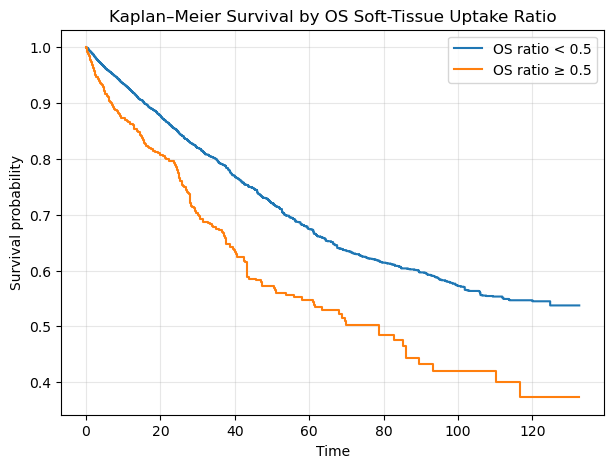

In [41]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

kmf = KaplanMeierFitter()

plt.figure(figsize=(7,5))

for g, label in zip([0,1], ["OS ratio < 0.5", "OS ratio ≥ 0.5"]):
    mask = analysis["OS_group"] == g
    kmf.fit(
        durations=analysis.loc[mask, "time"],
        event_observed=analysis.loc[mask, "event"],
        label=label
    )
    kmf.plot_survival_function(ci_show=False)

plt.title("Kaplan–Meier Survival by OS Soft-Tissue Uptake Ratio")
plt.xlabel("Time")
plt.ylabel("Survival probability")
plt.grid(alpha=0.3)
plt.show()


In [56]:
from lifelines.statistics import logrank_test

g0 = analysis[analysis["OS_group"] == 0]
g1 = analysis[analysis["OS_group"] == 1]

res = logrank_test(
    g0["time"], g1["time"],
    event_observed_A=g0["event"],
    event_observed_B=g1["event"]
)

print("Logrank p-value:", res.p_value)



Logrank p-value: 5.359608176482952e-13


In [57]:
# Cox Modell Binär
from lifelines import CoxPHFitter

cox_df = analysis[["time","event","OS_group"]].dropna()

cph = CoxPHFitter()
cph.fit(cox_df, duration_col="time", event_col="event")

cph.print_summary()


<lifelines.CoxPHFitter: fitted with 8782 total observations, 6161 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 8782
number of events observed = 2621
   partial log-likelihood = -22327.46
         time fit was run = 2026-02-19 12:47:10 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
OS_group   0.49      1.63      0.07            0.35            0.62                1.42                1.86

           cmp to    z      p  -log2(p)
covariate                              
OS_group     0.00 7.14 <0.005     40.01
---
Concordance = 0.52
Partial AIC = 44656.93
log-likelihood ratio test = 44.79 on 1 df
-log2(p) of ll-ratio test = 35.41

In [58]:
# Cox modell binär ohne schwelle
cox_df2 = analysis[["time","event","OS_ratio"]].dropna()

cph2 = CoxPHFitter()
cph2.fit(cox_df2, duration_col="time", event_col="event")

cph2.print_summary()



<lifelines.CoxPHFitter: fitted with 8782 total observations, 6161 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 8782
number of events observed = 2621
   partial log-likelihood = -22323.23
         time fit was run = 2026-02-19 12:47:35 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
OS_ratio   1.66      5.24      0.22            1.22            2.10                3.37                8.13

           cmp to    z      p  -log2(p)
covariate                              
OS_ratio     0.00 7.38 <0.005     42.50
---
Concordance = 0.54
Partial AIC = 44648.46
log-likelihood ratio test = 53.26 on 1 df
-log2(p) of ll-ratio test = 41.64

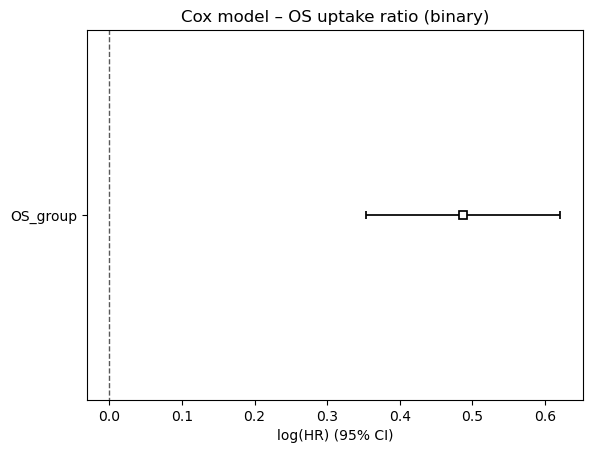

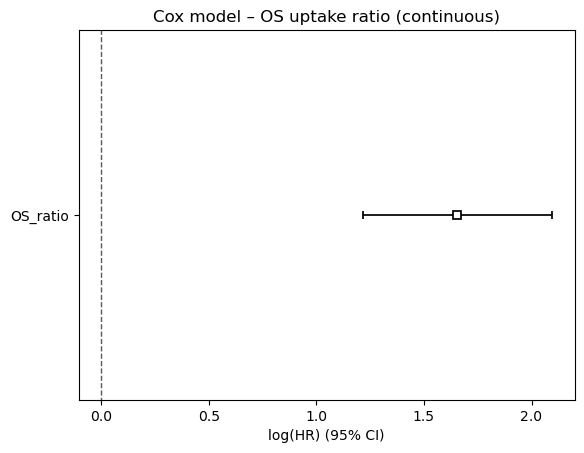

In [45]:
cph.plot()
plt.title("Cox model – OS uptake ratio (binary)")
plt.show()

cph2.plot()
plt.title("Cox model – OS uptake ratio (continuous)")
plt.show()


In [53]:
def summarize_cph(cph, varname):
    s = cph.summary.loc[varname]
    hr = s["exp(coef)"]
    lo = s["exp(coef) lower 95%"]
    hi = s["exp(coef) upper 95%"]
    p  = s["p"]
    return hr, lo, hi, p

# --- OS summaries ---
hr_bin, lo_bin, hi_bin, p_bin = summarize_cph(cph_os_bin, "OS_group")
hr_con, lo_con, hi_con, p_con = summarize_cph(cph_os_cont, "OS_ratio")

print(f"OS binary Cox (>=0.5): HR={hr_bin:.2f} (95% CI {lo_bin:.2f}-{hi_bin:.2f}), p={p_bin:.3g}")
print(f"OS continuous Cox:     HR={hr_con:.2f} (95% CI {lo_con:.2f}-{hi_con:.2f}), p={p_con:.3g}")

# Logrank (nur wenn res_os existiert)
if "res_os" in locals():
    print("OS Logrank p:", res_os.p_value)
else:
    print("OS Logrank p: (res_os not found – run logrank cell first)")


NameError: name 'cph_os_bin' is not defined

In [59]:
[v for v in locals() if v.startswith("cph")]


['cph', 'cph2', 'cph_us_bin', 'cph_us_cont', 'cph_os_bin', 'cph_os_cont']

In [46]:
###
analysis[["time","event","US_ratio"]].describe()
analysis["US_ratio"].isna().sum()
analysis = analysis.copy()
analysis["US_group"] = (analysis["US_ratio"] >= 0.5).astype(int)

print(analysis["US_group"].value_counts())


US_group
0    8100
1     682
Name: count, dtype: int64


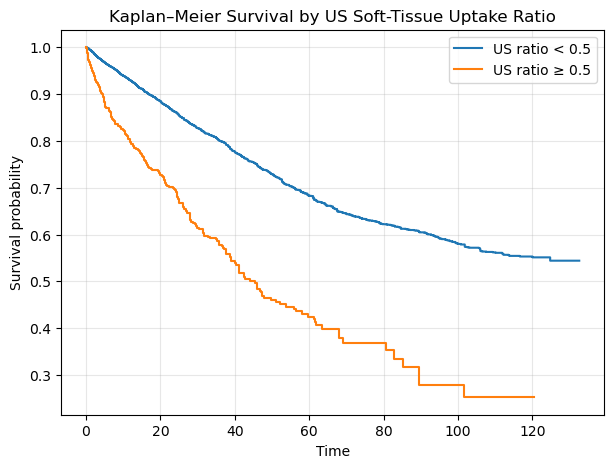

In [47]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

kmf = KaplanMeierFitter()

plt.figure(figsize=(7,5))

for g, label in zip([0,1], ["US ratio < 0.5", "US ratio ≥ 0.5"]):
    mask = analysis["US_group"] == g
    kmf.fit(
        durations=analysis.loc[mask, "time"],
        event_observed=analysis.loc[mask, "event"],
        label=label
    )
    kmf.plot_survival_function(ci_show=False)

plt.title("Kaplan–Meier Survival by US Soft-Tissue Uptake Ratio")
plt.xlabel("Time")
plt.ylabel("Survival probability")
plt.grid(alpha=0.3)
plt.show()


In [48]:
from lifelines.statistics import logrank_test

g0 = analysis[analysis["US_group"] == 0]
g1 = analysis[analysis["US_group"] == 1]

res_us = logrank_test(
    g0["time"], g1["time"],
    event_observed_A=g0["event"],
    event_observed_B=g1["event"]
)

print("US Logrank p-value:", res_us.p_value)


US Logrank p-value: 1.329905606689961e-51


In [49]:
# Cox modell kontinuierlich
from lifelines import CoxPHFitter

cox_df_us_bin = analysis[["time","event","US_group"]].dropna()

cph_us_bin = CoxPHFitter()
cph_us_bin.fit(cox_df_us_bin, duration_col="time", event_col="event")

cph_us_bin.print_summary()


<lifelines.CoxPHFitter: fitted with 8782 total observations, 6161 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 8782
number of events observed = 2621
   partial log-likelihood = -22264.44
         time fit was run = 2026-02-19 12:43:28 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
US_group   0.91      2.47      0.06            0.78            1.03                2.19                2.79

           cmp to     z      p  -log2(p)
covariate                               
US_group     0.00 14.61 <0.005    158.24
---
Concordance = 0.54
Partial AIC = 44530.87
log-likelihood ratio test = 170.84 on 1 df
-log2(p) of ll-ratio test = 127.28

In [50]:
# Cox modell binär
cox_df_us_cont = analysis[["time","event","US_ratio"]].dropna()

cph_us_cont = CoxPHFitter()
cph_us_cont.fit(cox_df_us_cont, duration_col="time", event_col="event")

cph_us_cont.print_summary()


<lifelines.CoxPHFitter: fitted with 8782 total observations, 6161 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 8782
number of events observed = 2621
   partial log-likelihood = -22207.84
         time fit was run = 2026-02-19 12:43:54 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
US_ratio   3.31     27.29      0.19            2.94            3.67               18.87               39.45

           cmp to     z      p  -log2(p)
covariate                               
US_ratio     0.00 17.58 <0.005    227.43
---
Concordance = 0.59
Partial AIC = 44417.69
log-likelihood ratio test = 284.03 on 1 df
-log2(p) of ll-ratio test = 209.29

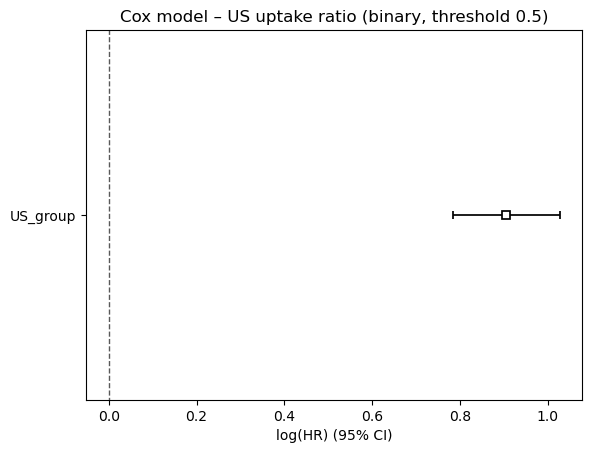

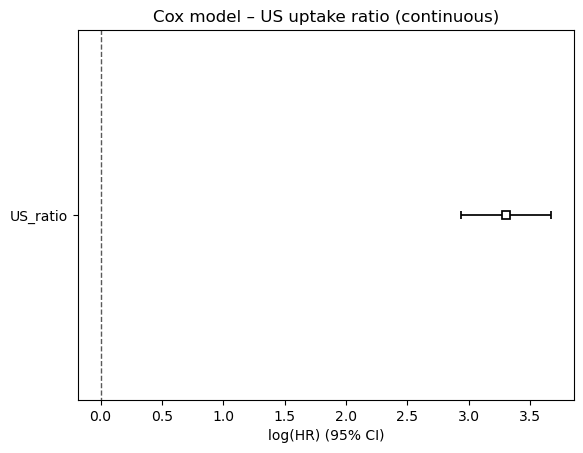

In [51]:
import matplotlib.pyplot as plt

cph_us_bin.plot()
plt.title("Cox model – US uptake ratio (binary, threshold 0.5)")
plt.show()

cph_us_cont.plot()
plt.title("Cox model – US uptake ratio (continuous)")
plt.show()


In [52]:
def summarize_cph(cph, varname):
    s = cph.summary.loc[varname]
    hr = s["exp(coef)"]
    lo = s["exp(coef) lower 95%"]
    hi = s["exp(coef) upper 95%"]
    p  = s["p"]
    return hr, lo, hi, p

hr_bin, lo_bin, hi_bin, p_bin = summarize_cph(cph_us_bin, "US_group")
hr_con, lo_con, hi_con, p_con = summarize_cph(cph_us_cont, "US_ratio")

print(f"US binary Cox (>=0.5): HR={hr_bin:.2f} (95% CI {lo_bin:.2f}-{hi_bin:.2f}), p={p_bin:.3g}")
print(f"US continuous Cox:     HR={hr_con:.2f} (95% CI {lo_con:.2f}-{hi_con:.2f}), p={p_con:.3g}")
print("US Logrank p:", res_us.p_value)


US binary Cox (>=0.5): HR=2.47 (95% CI 2.19-2.79), p=2.31e-48
US continuous Cox:     HR=27.29 (95% CI 18.87-39.45), p=3.45e-69
US Logrank p: 1.329905606689961e-51
